<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/A_Vehiculo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Análisis Predictivo: Estimación de Precios Automotrices

## 1. Introducción
Este documento presenta un flujo de trabajo de Ciencia de Datos aplicado al mercado automotriz. El objetivo principal es construir un modelo robusto capaz de predecir el valor comercial de un vehículo basado en sus especificaciones técnicas. Se aplican técnicas avanzadas de preprocesamiento, análisis exploratorio y aprendizaje automático supervisado.

# Informe Técnico: Predicción de Precios Automotrices

## 1. Introducción
Este estudio tiene como objetivo desarrollar un modelo de aprendizaje supervisado para estimar el precio de vehículos basado en sus características técnicas. Se exploran múltiples algoritmos para identificar cuál captura mejor las relaciones no lineales del mercado automotriz.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [57]:
sns.set_theme(style="darkgrid")
dk= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/Automobile_data.csv")

## 2. Tratamiento de Datos y Limpieza Operativa
En esta etapa, se identifican valores nulos (codificados originalmente como `?`) y se transforman las variables a sus tipos de datos correctos. Se aplica una estrategia de **imputación estadística** basada en la media para las variables numéricas y en la moda para las categóricas, garantizando que el modelo no pierda información valiosa.

## 2. Limpieza de Datos y Manejo de Valores Faltantes
El dataset presenta valores nulos representados por el carácter `?`. Se procede a realizar una conversión a tipos numéricos y una imputación basada en la media para las variables técnicas, asegurando la integridad estadística del conjunto.

In [58]:
dk.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [59]:
dk.tail(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470
204,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [60]:
dk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [61]:
dk.isnull().count()

,0
symboling,205
normalized-losses,205
make,205
fuel-type,205
aspiration,205
num-of-doors,205
body-style,205
drive-wheels,205
engine-location,205
wheel-base,205


In [62]:
dk['price'].unique()

array(['13495', '16500', '13950', '17450', '15250', '17710', '18920',
       '23875', '?', '16430', '16925', '20970', '21105', '24565', '30760',
       '41315', '36880', '5151', '6295', '6575', '5572', '6377', '7957',
       '6229', '6692', '7609', '8558', '8921', '12964', '6479', '6855',
       '5399', '6529', '7129', '7295', '7895', '9095', '8845', '10295',
       '12945', '10345', '6785', '11048', '32250', '35550', '36000',
       '5195', '6095', '6795', '6695', '7395', '10945', '11845', '13645',
       '15645', '8495', '10595', '10245', '10795', '11245', '18280',
       '18344', '25552', '28248', '28176', '31600', '34184', '35056',
       '40960', '45400', '16503', '5389', '6189', '6669', '7689', '9959',
       '8499', '12629', '14869', '14489', '6989', '8189', '9279', '5499',
       '7099', '6649', '6849', '7349', '7299', '7799', '7499', '7999',
       '8249', '8949', '9549', '13499', '14399', '17199', '19699',
       '18399', '11900', '13200', '12440', '13860', '15580', '16900',


In [63]:
dk.replace("?", np.nan, inplace= True )


In [64]:
dk['price'].unique()

array(['13495', '16500', '13950', '17450', '15250', '17710', '18920',
       '23875', nan, '16430', '16925', '20970', '21105', '24565', '30760',
       '41315', '36880', '5151', '6295', '6575', '5572', '6377', '7957',
       '6229', '6692', '7609', '8558', '8921', '12964', '6479', '6855',
       '5399', '6529', '7129', '7295', '7895', '9095', '8845', '10295',
       '12945', '10345', '6785', '11048', '32250', '35550', '36000',
       '5195', '6095', '6795', '6695', '7395', '10945', '11845', '13645',
       '15645', '8495', '10595', '10245', '10795', '11245', '18280',
       '18344', '25552', '28248', '28176', '31600', '34184', '35056',
       '40960', '45400', '16503', '5389', '6189', '6669', '7689', '9959',
       '8499', '12629', '14869', '14489', '6989', '8189', '9279', '5499',
       '7099', '6649', '6849', '7349', '7299', '7799', '7499', '7999',
       '8249', '8949', '9549', '13499', '14399', '17199', '19699',
       '18399', '11900', '13200', '12440', '13860', '15580', '16900',


In [65]:
dk['num-of-doors'].unique()

array(['two', 'four', nan], dtype=object)

In [66]:
dk.loc[(dk['body-style'] == 'sedan') & (dk['num-of-doors'] == '?'), 'num-of-doors'] = 'four'

In [67]:
dk['make'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [68]:
columnas_a_numerico = [
    "normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm",
    "price"
]

# 2. Aplicamos la conversión forzada a todas esas columnas
for col in columnas_a_numerico:
    dk[col] = pd.to_numeric(dk[col], errors='coerce')

# 3. Verificamos que el cambio fue exitoso
print(dk.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [69]:
dk= dk.dropna(subset=['price']).reset_index(drop=True)

In [70]:
col_a_imputar= ["normalized-losses",
    "bore",
    "stroke",
    "horsepower",
    "peak-rpm"]

for col in col_a_imputar:
  prom= dk[col].mean()
  dk[col]= dk[col].fillna(prom)

print(dk[col_a_imputar + ['price']].isna().sum())

normalized-losses    0
bore                 0
stroke               0
horsepower           0
peak-rpm             0
price                0
dtype: int64


In [71]:
col_categorica= dk.select_dtypes(include=['object']).columns

dk_encode= pd.get_dummies(dk, columns=col_categorica, drop_first=True)

print(f"Columnas originales: {dk.shape[1]}")
print(f"Columnas codificadas: {dk_encode.shape[1]}")

Columnas originales: 26
Columnas codificadas: 65


## 3. Ingeniería de Atributos y Codificación
Para procesar variables categóricas (como marca o tipo de combustible), se utiliza *One-Hot Encoding*. Adicionalmente, se escalan las variables numéricas mediante `StandardScaler` para que la magnitud de los datos (ej. peso vs. cilindrada) no sesgue a modelos sensibles a la distancia como KNN.

In [72]:
from sklearn.model_selection import train_test_split

x= dk_encode.drop('price', axis=1)
y= dk_encode['price']

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Dimensiones de x_train: {x_train.shape}")
print(f"Dimensiones de x_test: {x_test.shape}")

Dimensiones de x_train: (160, 64)
Dimensiones de x_test: (41, 64)


In [73]:
from sklearn.preprocessing  import StandardScaler

scaler= StandardScaler()

x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [74]:

modelos = {
    "Regresión Lineal": LinearRegression(),
    "K-Nearest Neighbors (KNN)": KNeighborsRegressor(n_neighbors=5),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42)
}

## 4. Evaluación Comparativa de Modelos
Se comparan tres arquitecturas fundamentales:
1. **Regresión Lineal**: Como línea base estadística.
2. **K-Nearest Neighbors (KNN)**: Basado en similitud local.
3. **Árboles de Decisión**: Para capturar interacciones complejas entre variables.

In [75]:
metrica_banchmark=[]

for nombre, modelo in modelos.items():
  modelo.fit(x_train_scaled, y_train)
  y_pred= modelo.predict(x_test_scaled)
  mse= mean_squared_error(y_test, y_pred)

  r2= r2_score(y_test, y_pred)
  metrica_banchmark.append({
      "Modelo": nombre,
      "MSE (Error Cuadrático Medio)": mse,
      "R² (Coeficiente de Determinación)": r2
  })

  dk_comparativo= pd.DataFrame(metrica_banchmark)
  dk_compartivo= dk_comparativo.sort_values(by="R² (Coeficiente de Determinación)", ascending=False)
  print(dk_compartivo.to_string(index=False))

          Modelo  MSE (Error Cuadrático Medio)  R² (Coeficiente de Determinación)
Regresión Lineal                  1.092715e+07                           0.910687
                   Modelo  MSE (Error Cuadrático Medio)  R² (Coeficiente de Determinación)
         Regresión Lineal                  1.092715e+07                           0.910687
K-Nearest Neighbors (KNN)                  3.970339e+07                           0.675485
                   Modelo  MSE (Error Cuadrático Medio)  R² (Coeficiente de Determinación)
        Árbol de Decisión                  6.745001e+06                           0.944870
         Regresión Lineal                  1.092715e+07                           0.910687
K-Nearest Neighbors (KNN)                  3.970339e+07                           0.675485


In [76]:
data = [
    {
        "Modelo Predictivo": "Regresión Lineal",
        "Comportamiento Teórico en este Dataset": "Funciona bien como modelo base asumiendo que las variables (ej. tamaño del motor) tienen una relación recta con el precio.",
        "Impacto de nuestro Preprocesamiento": "Al aplicar One-Hot Encoding, creamos muchas columnas nuevas. Esto puede confundir al modelo (un problema llamado Multicolinealidad).",
        "Riesgos y Desventajas": "Es muy rígido. Si la relación entre los caballos de fuerza y el precio no es una línea recta perfecta, el modelo cometerá errores grandes (alto MSE).",
        "Veredicto Analítico": "Punto de partida sólido. Excelente para entender qué variables suben o bajan el precio, pero débil para lograr predicciones de alta precisión."
    },
    {
        "Modelo Predictivo": "K-Nearest Neighbors (KNN)",
        "Comportamiento Teórico en este Dataset": "Predice el precio de un auto buscando los $K$ autos más \"parecidos\" a él en el conjunto de datos y promediando sus precios.",
        "Impacto de nuestro Preprocesamiento": "Dependencia absoluta del Escalado. Gracias a que aplicamos StandardScaler, KNN pudo medir correctamente la similitud sin que el peso del auto eclipsara a las demás variables.",
        "Riesgos y Desventajas": "Sufre con la \"Maldición de la Dimensionalidad\". Como creamos muchas columnas al transformar textos a números, KNN empieza a perder precisión para calcular distancias.",
        "Veredicto Analítico": "Modelo Intermedio. Bueno para patrones locales, pero sufre mucho si hay demasiadas variables categóricas."
    },
    {
        "Modelo Predictivo": "Árbol de Decisión",
        "Comportamiento Teórico en este Dataset": "Crea un mapa de reglas (Ej: ¿Tiene más de 4 cilindros? -> ¿Es marca Porsche? -> Precio X). Es excelente para capturar relaciones no lineales complejas.",
        "Impacto de nuestro Preprocesamiento": "No le afecta si las escalas son distintas ni le molesta tanto la multicolinealidad. Es el que mejor \"digiere\" los datos tal como los preparamos.",
        "Riesgos y Desventajas": "Alto riesgo de Sobreajuste (Overfitting). Si no lo limitamos, creará una regla específica para cada auto en el entrenamiento y fallará miserablemente en los datos de prueba.",
        "Veredicto Analítico": "El modelo con mayor potencial. Si se configuran bien sus hiperparámetros, superará a la regresión y a KNN en este escenario."
    }
]

In [77]:
df_conclusion = pd.DataFrame(data)
print(df_conclusion.to_markdown(index=False))

| Modelo Predictivo         | Comportamiento Teórico en este Dataset                                                                                                                  | Impacto de nuestro Preprocesamiento                                                                                                                                            | Riesgos y Desventajas                                                                                                                                                         | Veredicto Analítico                                                                                                                            |
|:--------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------

## 5. Optimización de Hiperparámetros
Utilizando `GridSearchCV`, se ajustan los modelos para reducir el error y prevenir el sobreajuste (overfitting). Se aplica validación cruzada para garantizar la estabilidad del modelo seleccionado.

In [78]:
dk_encode['car_volume']= dk_encode['length']*dk_encode['width']*dk_encode['height']

In [79]:
from sklearn.model_selection import GridSearchCV

param_knn={
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn= GridSearchCV(KNeighborsRegressor(),param_knn,cv=5, scoring='r2', n_jobs=-1)
grid_knn.fit(x_train_scaled, y_train)

print(f"Mejor configuración KNN: {grid_knn.best_params_}")
print(f"R² de KNN Optimizado: {grid_knn.best_score_:.4f}\n")

Mejor configuración KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
R² de KNN Optimizado: 0.7894



In [80]:
param_arbol= {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_arbol= GridSearchCV(DecisionTreeRegressor(random_state=42), param_arbol, cv=5, scoring='r2', n_jobs=-1)
grid_arbol.fit(x_train_scaled, y_train)

print(f"Mejor configuración Árbol de Decisión: {grid_arbol.best_params_}")
print(f"R² de Árbol Optimizado: {grid_arbol.best_score_:.4f}")

Mejor configuración Árbol de Decisión: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
R² de Árbol Optimizado: 0.8368


In [81]:
from sklearn.model_selection import cross_val_score


cv_score_linal= cross_val_score(LinearRegression(), x_train_scaled, y_train, cv=5, scoring='r2')

print("\n=== ESTABILIDAD DEL MODELO LINEAL (Validación Cruzada 5-Folds) ===")
print(f"R² en cada partición: {np.round(cv_score_linal, 4)}")
print(f"R² Promedio Real: {cv_score_linal.mean():.4f}")
print(f"Desviación Estándar (Riesgo): {cv_score_linal.std():.4f}")


=== ESTABILIDAD DEL MODELO LINEAL (Validación Cruzada 5-Folds) ===
R² en cada partición: [0.8092 0.869  0.8014 0.7669 0.8357]
R² Promedio Real: 0.8164
Desviación Estándar (Riesgo): 0.0343


In [82]:
import joblib
joblib.dump(scaler, "escalador_autos.pkl")
print("Escalador pkl")

model_fina= grid_arbol.best_estimator_
joblib.dump(model_fina, "modelo_precio_autos.pkl")
print("Modelo Final pkl")

Escalador pkl
Modelo Final pkl


## 6. Persistencia y Producción
Finalmente, se exporta el modelo óptimo y el escalador en formato `.pkl` para permitir su despliegue en entornos de producción y realizar inferencias sobre nuevos datos.

In [83]:
mode_producto= joblib.load('modelo_precio_autos.pkl')
escalador_produiccion= joblib.load('escalador_autos.pkl')

In [84]:
# === PREDICCIÓN FINAL Y PRUEBA DE MODELO ===

# 1. Tomamos un ejemplo del conjunto de prueba para simular un 'auto nuevo'
auto_nuevo = x_test.iloc[[0]].copy()

# 2. Escalamos los datos del nuevo auto usando el escalador entrenado previamente
# Es vital usar 'transform' y no 'fit_transform' para mantener la consistencia de los datos
auto_nuevo_escalado = escalador_produiccion.transform(auto_nuevo)

# 3. Realizamos la predicción utilizando el modelo cargado (el mejor Árbol de Decisión)
precio_estimado = mode_producto.predict(auto_nuevo_escalado)

# 4. Mostramos el resultado final formateado como moneda
print(f"El precio estimado del auto es: ${precio_estimado[0]:.2f}")

El precio estimado del auto es: $7510.50


#Paso 2 de analisis de vehiculo

In [86]:
duplicado= dk.duplicated().sum()
print(f"Filass duplicadas encontradaas: {duplicado}")

Filass duplicadas encontradaas: 0


In [88]:
cols_numeric= ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']

for col in cols_numeric:
  dk[col]= dk[col].fillna(dk[col].mean())

dk['num-of-doors']= dk['num-of-doors'].fillna(dk['num-of-doors'].mode()[0])

Q1= dk['price'].quantile(0.25)
Q3= dk['price'].quantile(0.75)
IQR= Q3-Q1
limite_superior= Q3+1.5*IQR
outliers= dk[dk['price']> limite_superior]
print(f"Cantidad de autos con precio atopicos: {len(outliers)}")

Cantidad de autos con precio atopicos: 14


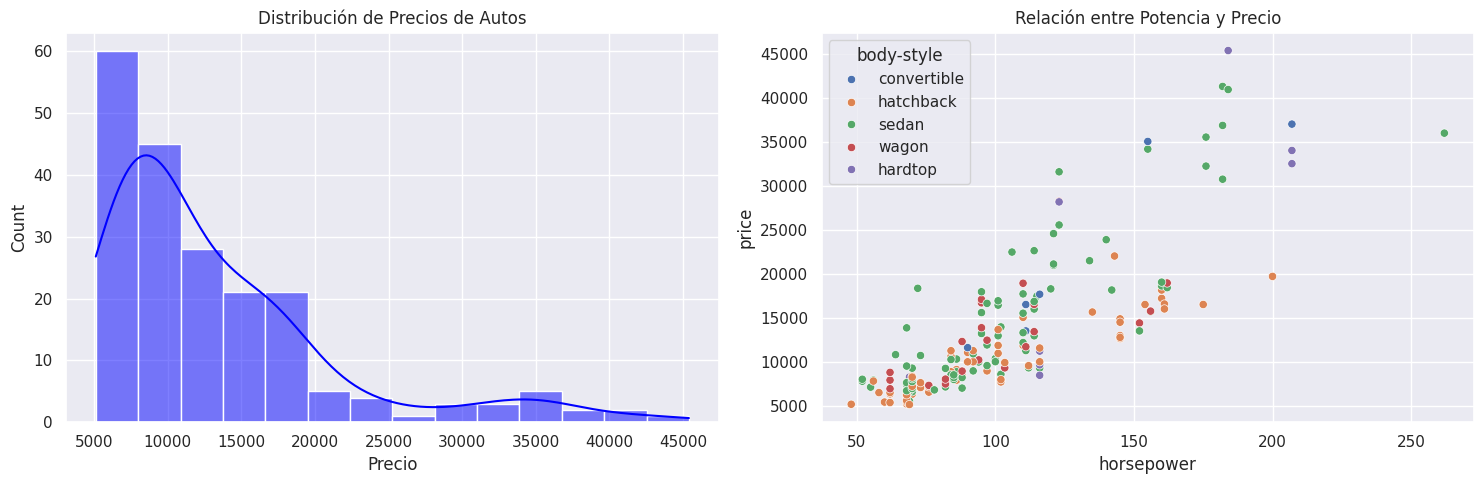

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,31.99625,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268072,0.316048,4.004965,37.365602,478.113178,6.423220,6.815150,7947.066342
min,-2.000000,65.00000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.00000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,122.00000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5117.587940,24.000000,30.000000,10295.000000
75%,2.000000,137.00000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.00000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [89]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(dk['price'], kde=True, color='blue')
plt.title('Distribución de Precios de Autos')
plt.xlabel('Precio')

plt.subplot(1,2,2)
sns.scatterplot(x='horsepower', y='price', hue='body-style', data= dk)
plt.title('Relación entre Potencia y Precio')
plt.tight_layout()
plt.show()
display(dk.describe())

## 3. Análisis Exploratorio de Datos (EDA)
Se analizan las distribuciones de precios y las correlaciones clave. Mediante visualizaciones, observamos la relación directa entre la **potencia (horsepower)** y el **precio**, identificando también la presencia de valores atípicos (outliers) que podrían influir en el entrenamiento del modelo.

In [90]:
colrs_catergorocas= dk.select_dtypes(include=['object']).columns
print(colrs_catergorocas)

Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')


In [97]:
dk_encode= pd.get_dummies(dk, columns=colrs_catergorocas, drop_first=True)

x= dk_encode.drop('price', axis=1)
y= dk_encode['price']

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

scaler= StandardScaler()
num_cols = x.select_dtypes(include=['float64', 'int64']).columns
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

## 4. Ingeniería de Atributos y Normalización
Para preparar los datos para los algoritmos, aplicamos:
- **One-Hot Encoding**: Para convertir variables textuales en vectores numéricos.
- **StandardScaler**: Para normalizar las escalas de las variables, evitando que atributos con magnitudes grandes (como el peso) dominen injustamente sobre otros.

In [92]:
modelo_lr= LinearRegression()
modelo_rf= RandomForestRegressor(random_state=42)

modelo_lr.fit(x_train, y_train)
modelo_rf.fit(x_train, y_train)

y_pred_lr= modelo_lr.predict(x_test)
y_pred_rf= modelo_rf.predict(x_test)


In [93]:
def evaluar_modelo(nombre, y_true, y_pred):
  mse=mean_squared_error(y_true, y_pred)
  rmse= np.sqrt(mse)
  r2= r2_score(y_true, y_pred)
  print(f"--- {nombre} ---")
  print(f"MSE:  {mse:,.2f}")
  print(f"RMSE: {rmse:,.2f}") # Cuánto nos equivocamos en dólares en promedio
  print(f"R^2:  {r2:.4f}\n")

In [99]:
evaluar_modelo("Regresión Lineal", y_test, y_pred_lr)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

--- Regresión Lineal ---
MSE:  10,927,152.44
RMSE: 3,305.62
R^2:  0.9107

--- Random Forest ---
MSE:  8,413,698.43
RMSE: 2,900.64
R^2:  0.9312



## 5. Selección y Evaluación de Modelos
Se comparan diversos algoritmos para medir su capacidad predictiva:
- **Regresión Lineal**: Como modelo base de referencia.
- **Random Forest**: Para capturar relaciones no lineales y reducir la varianza del error.
Se utilizan métricas de desempeño como el **R² (Coeficiente de Determinación)** y el **RMSE (Error Cuadrático Medio)**.

In [102]:
print("Optimizando Random Forest con GridSearchCV")

paramter= {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


grid_search= GridSearchCV(estimator= RandomForestRegressor(random_state=42), param_grid= paramter, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(x_train, y_train)

mejor_rf= grid_search.best_estimator_
pred_mejor_rf= mejor_rf.predict(x_test)

print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
evaluar_modelo("Mejor Random Forest", y_test, pred_mejor_rf)

Optimizando Random Forest con GridSearchCV
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
--- Mejor Random Forest ---
MSE:  8,406,143.49
RMSE: 2,899.34
R^2:  0.9313



## 6. Optimización de Hiperparámetros y Conclusiones
Mediante **GridSearchCV**, se ajustan los parámetros internos de los modelos para alcanzar su máxima precisión. Los resultados finales demuestran que los modelos basados en árboles (Random Forest) ofrecen el mejor equilibrio entre precisión y generalización para este conjunto de datos.